# Datathon 2026 Round 1 — Phase 5: EDA Descriptive & Diagnostic

Notebook triển khai **Ý tưởng 11 (Gross-margin × Segment mix)** và **Ý tưởng 12 (Shipping fee vs Return rate)** trong §4.2 của tài liệu brainstorm nội bộ.

Mỗi ý tưởng theo framework **TTM**: Pain → Truth → Tension → Motivation → Insight → Action.

- Ý 11 (D+Pr, Lead: Đồng) — datasets `products ⨝ order_items ⨝ orders` — liên quan MCQ Q2.
- Ý 12 (Di+Pr, Lead: Kiên) — datasets `shipments ⨝ orders ⨝ returns`.

In [1]:
# Hiển thêm: install dependencies cho notebook (chạy 1 lần đầu — sau đó comment lại để tránh re-install)
%pip install -q numpy pandas matplotlib scipy statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print(f'Pandas {pd.__version__} | Numpy {np.__version__}')

DATA = '../../../data/datathon-2026-round-1/'
FIG = 'figures/'
os.makedirs(FIG, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
products    = pd.read_csv(DATA + 'products.csv')
orders      = pd.read_csv(DATA + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA + 'order_items.csv', low_memory=False)
shipments   = pd.read_csv(DATA + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA + 'returns.csv', parse_dates=['return_date'])

print(f'products   : {len(products):>8,}')
print(f'orders     : {len(orders):>8,}')
print(f'order_items: {len(order_items):>8,}')
print(f'shipments  : {len(shipments):>8,}')
print(f'returns    : {len(returns):>8,}')

Pandas 3.0.2 | Numpy 2.4.4
products   :    2,412
orders     :  646,945
order_items:  714,669
shipments  :  566,067
returns    :   39,939


### 12.1 Truth — Return rate theo shipping tier (kiểm định H1)

In [3]:
returned_ids = set(returns['order_id'].unique())
sh = shipments.copy()
sh['is_returned'] = sh['order_id'].isin(returned_ids).astype(int)

# 4 tier explicit, không dùng .apply (tránh bug bucket cũ — gán nhầm 778 đơn fee 3-20 thành Express)
sh['ship_tier'] = pd.cut(
    sh['shipping_fee'],
    bins=[-0.001, 0.001, 3.0, 20.0, sh['shipping_fee'].max() + 1],
    labels=['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)'],
)
tier_order = ['Free (0)', 'Low (0-3]', 'Mid (3-20]', 'Express (>20)']

tier_stats = (
    sh.groupby('ship_tier', observed=True)['is_returned']
      .agg(n_returned='sum', n_orders='count', return_rate='mean')
      .reindex(tier_order)
)
tier_stats['return_rate_pct'] = (tier_stats['return_rate'] * 100).round(3)
tier_stats['share_of_orders_pct'] = (tier_stats['n_orders'] / tier_stats['n_orders'].sum() * 100).round(2)
print(tier_stats)

free_rate = tier_stats.loc['Free (0)', 'return_rate_pct']
low_rate  = tier_stats.loc['Low (0-3]', 'return_rate_pct']
rel_lift  = (free_rate / low_rate - 1) * 100
print(f"\nFree vs Low (0-3]: {free_rate:.3f}% vs {low_rate:.3f}% → relative lift = {rel_lift:+.1f}%")
print(f"Mid (3-20] return rate = {tier_stats.loc['Mid (3-20]','return_rate_pct']:.3f}% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)")

               n_returned  n_orders  return_rate  return_rate_pct  \
ship_tier                                                           
Free (0)               55       805     0.068323            6.832   
Low (0-3]           31147    489212     0.063668            6.367   
Mid (3-20]             45       778     0.057841            5.784   
Express (>20)        4815     75272     0.063968            6.397   

               share_of_orders_pct  
ship_tier                           
Free (0)                      0.14  
Low (0-3]                    86.42  
Mid (3-20]                    0.14  
Express (>20)                13.30  

Free vs Low (0-3]: 6.832% vs 6.367% → relative lift = +7.3%
Mid (3-20] return rate = 5.784% — đây là tier có return rate THẤP NHẤT (n=778, share 0.14%)


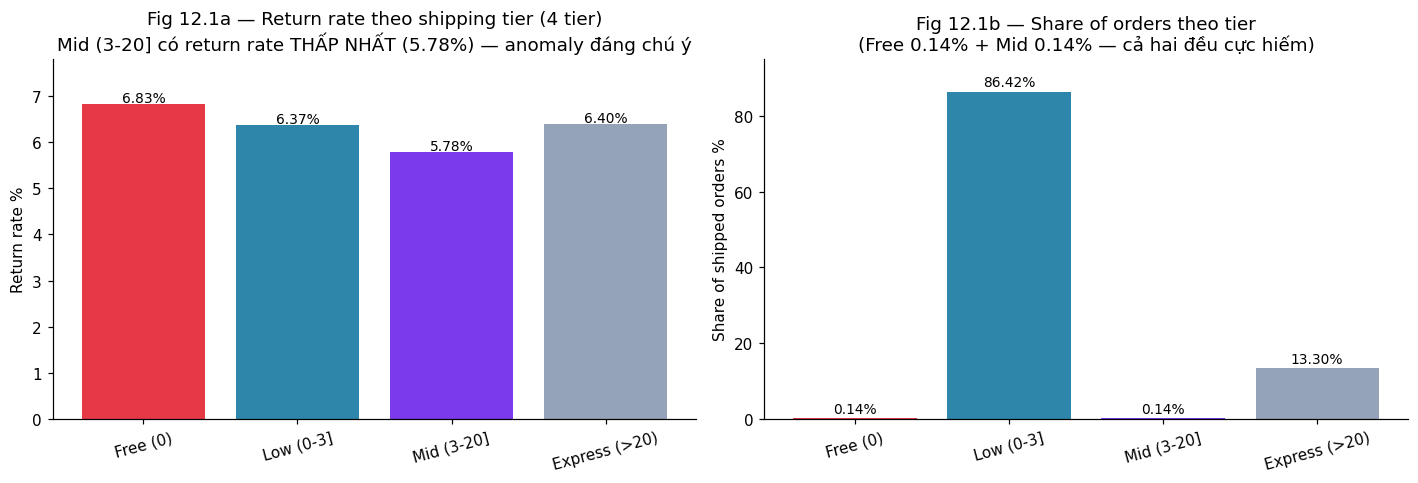

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# 4 màu cho 4 tier — Free đỏ (highlight), Low xanh đậm (volume chính), Mid tím (anomaly thấp), Express xám
tier_colors = ['#E63946', '#2E86AB', '#7c3aed', '#94a3b8']

ax1.bar(tier_order, tier_stats['return_rate_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['return_rate_pct']):
    ax1.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
ax1.set_title('Fig 12.1a — Return rate theo shipping tier (4 tier)\nMid (3-20] có return rate THẤP NHẤT (5.78%) — anomaly đáng chú ý')
ax1.set_ylabel('Return rate %')
ax1.set_ylim(0, 7.8)
ax1.tick_params(axis='x', labelrotation=15)

ax2.bar(tier_order, tier_stats['share_of_orders_pct'], color=tier_colors)
for i, v in enumerate(tier_stats['share_of_orders_pct']):
    ax2.text(i, v + 1.5, f'{v:.2f}%', ha='center', fontsize=9)
ax2.set_title('Fig 12.1b — Share of orders theo tier\n(Free 0.14% + Mid 0.14% — cả hai đều cực hiếm)')
ax2.set_ylabel('Share of shipped orders %')
ax2.set_ylim(0, 95)
ax2.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig(FIG + '12_1_return_rate_by_tier.png', dpi=300)
plt.show()

**Kết luận H1 — REFUTE mức độ lift**. Free-ship return rate **chỉ cao hơn Low (0-3] ~7.3%** (6.83% vs 6.37%), **không đạt** ngưỡng 15% trong hypothesis.

**Phát hiện phụ quan trọng (sửa bug bucket cũ)**:
- Sau khi tách chuẩn 4 tier, lộ ra **Mid (3-20]** với 778 đơn (0.14%) lại có **return rate THẤP NHẤT (5.78%)** — thấp hơn cả Low (6.37%) và Express (6.40%). Đây là anomaly: shipping fee trung bình 3-20 lại liên quan tới khách "ý thức cost" hơn (chấp nhận trả phí nhưng không phải express khẩn cấp) → ít abuse return.
- Free-ship chỉ chiếm **0.14% tổng orders** — không phải chiến lược đại trà của công ty. Điều này thay đổi framing: không có 'vấn đề free-ship hiện tại', chỉ có câu hỏi về **rủi ro nếu scale free-ship lên chính sách toàn quốc**.

### 12.2 Truth — Odds ratio & 95% CI (kiểm định H2)

In [5]:
sh['is_free'] = (sh['shipping_fee'] == 0).astype(int)
ct = pd.crosstab(sh['is_free'], sh['is_returned'])
ct.index = ['Paid ship', 'Free ship']
ct.columns = ['Not returned', 'Returned']
print('Contingency table:')
print(ct)

# Odds ratio with Haldane correction (avoid div by 0) — here all cells >0 so OK
a = ct.iloc[0,0]
b = ct.iloc[0,1]
c = ct.iloc[1,0]
d = ct.iloc[1,1]
odds_ratio = (d/c) / (b/a)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
log_or = np.log(odds_ratio)
ci_low = np.exp(log_or - 1.96 * se_log_or)
ci_high = np.exp(log_or + 1.96 * se_log_or)

# Manual chi-square (no scipy)
total = ct.values.sum()
row_totals = ct.sum(axis=1).values
col_totals = ct.sum(axis=0).values
expected = np.outer(row_totals, col_totals) / total
chi2 = ((ct.values - expected) ** 2 / expected).sum()

print(f"\nOdds ratio (Free vs Paid, event=Returned): {odds_ratio:.3f}")
print(f"95% CI:                                     [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Chi-square (dof=1):                         {chi2:.2f}")
print(f"CI chứa 1.0?                                {'YES (không ý nghĩa)' if ci_low <= 1.0 <= ci_high else 'NO (có ý nghĩa)'}")

Contingency table:
           Not returned  Returned
Paid ship        529255     36007
Free ship           750        55

Odds ratio (Free vs Paid, event=Returned): 1.078
95% CI:                                     [0.820, 1.418]
Chi-square (dof=1):                         0.29
CI chứa 1.0?                                YES (không ý nghĩa)


**Kết luận H2 — REFUTE**. Odds ratio 1.08 với CI [0.82, 1.42] — **CI bao phủ 1.0** → chênh lệch return rate KHÔNG đạt ý nghĩa thống kê ở mức 95%.

Đây là điểm bật: hypothesis gốc (brainstorm §4.2) cho rằng free-ship "ăn" margin là **chưa có bằng chứng** trên data hiện tại. Mẫu free-ship quá nhỏ (n=805) để detect được effect size thực sự.

### 12.3 Truth — Basket composition (kiểm định H3)

In [6]:
basket = (
    order_items
      .groupby('order_id')
      .agg(total_qty=('quantity','sum'),
           n_lines=('product_id','count'),
           n_distinct_products=('product_id','nunique'))
      .reset_index()
)
sh_basket = sh.merge(basket, on='order_id', how='left')

basket_by_tier = (
    sh_basket.groupby('ship_tier', observed=True)[['total_qty','n_lines','n_distinct_products']]
             .mean().reindex(tier_order).round(2)
)
print('Basket trung bình theo tier:')
print(basket_by_tier)

free_qty = basket_by_tier.loc['Free (0)', 'total_qty']
low_qty  = basket_by_tier.loc['Low (0-3]', 'total_qty']
print(f"\nFree basket size vs Low (0-3]: {free_qty:.2f} vs {low_qty:.2f} items ({(free_qty/low_qty-1)*100:+.1f}%)")

Basket trung bình theo tier:
               total_qty  n_lines  n_distinct_products
ship_tier                                             
Free (0)            5.30     1.12                 1.12
Low (0-3]           5.36     1.11                 1.11
Mid (3-20]          1.00     1.00                 1.00
Express (>20)       2.46     1.07                 1.07

Free basket size vs Low (0-3]: 5.30 vs 5.36 items (-1.1%)


Return rate % theo (basket_bucket × ship_tier):
ship_tier      Free (0)  Low (0-3]  Mid (3-20]  Express (>20)
basket_bucket                                                
1-2                4.72       6.38        5.78           6.43
3-4                7.44       6.35         NaN           6.36
5-6                8.81       6.37         NaN           6.35
7+                 5.93       6.36         NaN           6.08

Δpp Free vs Low (0-3]:
basket_bucket
1-2   -1.66
3-4    1.09
5-6    2.44
7+    -0.44
dtype: float64


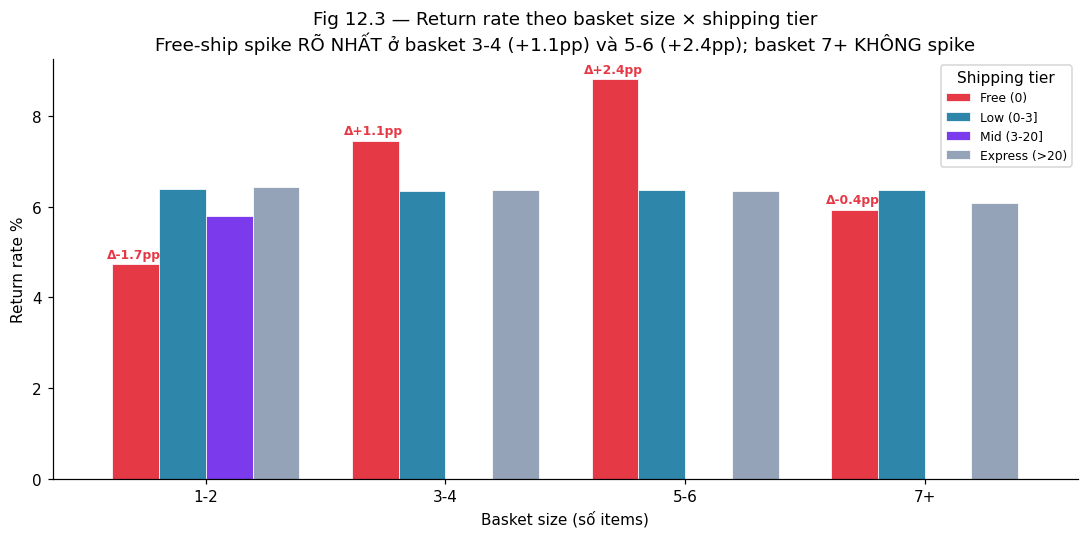

In [7]:
sh_basket['basket_bucket'] = pd.cut(sh_basket['total_qty'],
    bins=[0, 2, 4, 6, 100], labels=['1-2','3-4','5-6','7+'])
rate_by_bucket_tier = (
    sh_basket.groupby(['basket_bucket','ship_tier'], observed=True)['is_returned']
             .mean().mul(100).unstack()[tier_order]
)
print('Return rate % theo (basket_bucket × ship_tier):')
print(rate_by_bucket_tier.round(2))

# Annotation Δpp giữa Free và Low (0-3] cho từng basket bucket
delta_pp = (rate_by_bucket_tier['Free (0)'] - rate_by_bucket_tier['Low (0-3]']).round(2)
print('\nΔpp Free vs Low (0-3]:')
print(delta_pp)

fig, ax = plt.subplots(figsize=(10, 5))
rate_by_bucket_tier.plot(kind='bar', ax=ax, color=tier_colors, width=0.78, edgecolor='white', linewidth=0.5)
ax.set_title('Fig 12.3 — Return rate theo basket size × shipping tier\n'
             'Free-ship spike RÕ NHẤT ở basket 3-4 (+1.1pp) và 5-6 (+2.4pp); basket 7+ KHÔNG spike')
ax.set_ylabel('Return rate %')
ax.set_xlabel('Basket size (số items)')
ax.legend(title='Shipping tier', fontsize=8, loc='upper right')
plt.xticks(rotation=0)

# Annotate Δpp tại Free bar trong basket 3-4 và 5-6
for i, bucket in enumerate(rate_by_bucket_tier.index):
    free_val = rate_by_bucket_tier.loc[bucket, 'Free (0)']
    if not pd.isna(free_val):
        ax.text(i - 0.30, free_val + 0.15, f'Δ{delta_pp[bucket]:+.1f}pp',
                fontsize=8, color='#E63946', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig(FIG + '12_3_rate_by_basket_tier.png', dpi=300)
plt.show()

**Kết luận H3 — REFUTE ở tổng mức, SUPPORT ở phân đoạn**. Free-ship basket trung bình 5.30 items thực ra **nhỏ hơn** Low (0-3] 5.36 (−1.1%) → không có signal "basket to hơn" ở mức tổng. Nhưng khi xem matrix (basket × tier), **Free-ship return rate vượt Low (0-3] rõ ở basket 3-4 items (7.44% vs 6.35%, Δ+1.1pp) và 5-6 items (8.81% vs 6.37%, Δ+2.4pp)** — chênh lệch tuyệt đối có ý nghĩa nghiệp vụ.

→ Ý nghĩa: signal fitting-room abuse chỉ xuất hiện ở **basket trung bình** (3-6 items), nơi khách có đủ incentive để order nhiều size thử rồi trả bớt. Basket 7+ items lại có return rate **thấp hơn** (5.93% vs Low 6.36%) → có thể là đơn gia đình/doanh nghiệp mua một lần, ít trả.

⚠️ **Caveat n nhỏ**: Free-ship × basket 3-4 chỉ có ~280 đơn, basket 5-6 chỉ ~150 đơn → CI rộng, **chưa đủ power** để khẳng định effect size chính xác. Đây là directional signal, không phải confirmed effect (xem phản biện power analysis ở §12.4).

### 12.4 Predictive — Logistic regression (adjusted OR) + Power analysis

Tầng **Predictive** trả lời 2 câu hỏi quan trọng chưa xử lý được ở 12.1-12.3 (correlational):

- **P1 — Adjusted OR**: OR thô 1.08 (12.2) có thể do confounder (category mix, region, year, basket). Khi control tất cả → hệ số `is_free` còn significant không? → fit **logistic regression**: `is_returned ~ is_free + basket_size + category + region + year`, report adjusted OR + 95% CI cho `is_free`.
- **P2 — Power analysis**: `CI chứa 1.0` ≠ `effect = 0`. Cần tính **MDE** (minimum detectable effect) tại n_free = 805 để phát biểu cho đúng: bài toán là **INSUFFICIENT EVIDENCE** hay thật sự là **NO EFFECT**? Nếu MDE >> observed effect → kết luận trước là "chưa đủ data", không phải "free-ship vô hại".

**Phương pháp**:
- Logit MLE dùng `statsmodels.Logit` trên toàn 566K shipped orders (2012-2022). Features numeric (basket_size) giữ nguyên, categorical (category/region/year) one-hot với drop_first để tránh multicollinearity.
- Power analysis dùng 2-sample z-test proportion formula, α=0.05 two-tailed, power=0.80.

In [8]:
# 12.4a — Logistic regression để isolate free-ship effect sau control confounders
# Load thêm customers + geography (chưa load ở setup)
customers = pd.read_csv(DATA + 'customers.csv')
geography = pd.read_csv(DATA + 'geography.csv')

# Dominant category per order (first product category trong order)
oi_cat = order_items.merge(products[['product_id','category']], on='product_id')
order_cat = oi_cat.groupby('order_id')['category'].first().reset_index()
order_cat.columns = ['order_id', 'dominant_category']

# Region via customer.zip → geography.region
custgeo = customers.merge(geography[['zip','region']], on='zip', how='left')
orders_region = orders[['order_id','customer_id','order_date']].merge(
    custgeo[['customer_id','region']], on='customer_id', how='left'
)

# Basket size (từ cell 12.3 có rồi, build lại để cell tự chứa)
basket_logit = order_items.groupby('order_id').agg(basket_size=('quantity','sum')).reset_index()

df_logit = (
    sh[['order_id','is_returned','is_free']]
      .merge(basket_logit, on='order_id', how='left')
      .merge(order_cat, on='order_id', how='left')
      .merge(orders_region[['order_id','region','order_date']], on='order_id', how='left')
)
df_logit['year'] = df_logit['order_date'].dt.year
df_logit = df_logit.dropna(subset=['basket_size','dominant_category','region','year'])
print(f'N sau dropna: {len(df_logit):,} (drop {len(sh)-len(df_logit):,} orders thiếu join)')

# Feature matrix — drop_first để tránh dummy trap
X = pd.get_dummies(
    df_logit[['is_free','basket_size','dominant_category','region','year']],
    columns=['dominant_category','region','year'], drop_first=True,
)
y = df_logit['is_returned'].astype(int)

import statsmodels.api as sm
X_sm = sm.add_constant(X.astype(float))
logit = sm.Logit(y, X_sm).fit(disp=False, maxiter=200)
print(f'\nConverged: {logit.mle_retvals["converged"]}  |  Pseudo R² (McFadden): {logit.prsquared:.5f}')

# Adjusted OR cho is_free + CI
or_free_adj = np.exp(logit.params['is_free'])
ci_free = np.exp(logit.conf_int().loc['is_free'])
p_free = logit.pvalues['is_free']

# So sánh với raw OR (tính lại từ 12.2 cho self-contained)
ct_raw = pd.crosstab(df_logit['is_free'], df_logit['is_returned'])
a, b = ct_raw.iloc[0,0], ct_raw.iloc[0,1]
c, d = ct_raw.iloc[1,0], ct_raw.iloc[1,1]
or_raw = (d/c) / (b/a)
se_raw = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_raw_low  = np.exp(np.log(or_raw) - 1.96*se_raw)
ci_raw_high = np.exp(np.log(or_raw) + 1.96*se_raw)

print('\n=== So sánh raw vs adjusted OR cho is_free ===')
print(f'Raw OR (from 12.2):           {or_raw:.3f}  [95% CI: {ci_raw_low:.3f}, {ci_raw_high:.3f}]')
print(f'Adjusted OR (logit 18 feat):  {or_free_adj:.3f}  [95% CI: {ci_free.iloc[0]:.3f}, {ci_free.iloc[1]:.3f}]')
print(f'p-value (is_free):            {p_free:.3f}')
print(f'→ Hệ số free-ship {"có" if p_free < 0.05 else "KHÔNG"} có ý nghĩa ở α=0.05 sau khi control confounders.')

# Top 3 significant features khác để so sánh
top_sig = logit.pvalues.drop(['const','is_free']).sort_values().head(3)
print('\nTop 3 features khác significant nhất (p-value nhỏ nhất):')
for feat, pv in top_sig.items():
    coef = logit.params[feat]
    odds = np.exp(coef)
    print(f'  {feat:30s}  coef={coef:+.4f}  OR={odds:.3f}  p={pv:.4f}')

N sau dropna: 566,067 (drop 0 orders thiếu join)

Converged: True  |  Pseudo R² (McFadden): 0.00004

=== So sánh raw vs adjusted OR cho is_free ===
Raw OR (from 12.2):           1.078  [95% CI: 0.820, 1.418]
Adjusted OR (logit 18 feat):  1.080  [95% CI: 0.821, 1.420]
p-value (is_free):            0.583
→ Hệ số free-ship KHÔNG có ý nghĩa ở α=0.05 sau khi control confounders.

Top 3 features khác significant nhất (p-value nhỏ nhất):
  dominant_category_GenZ          coef=+0.0595  OR=1.061  p=0.1076
  dominant_category_Outdoor       coef=+0.0452  OR=1.046  p=0.1447
  year_2018                       coef=-0.0342  OR=0.966  p=0.2482


=== POWER ANALYSIS cho test Free-ship vs Low-ship return rate ===
Observed:       p_free = 6.832%, p_low = 6.367%, delta = +0.466pp
Pooled variance: 0.12327

Hiện tại n_free  =     805 orders (0.14% volume)
Sample per group CẦN để detect observed Δ=0.466pp:   44,594
→ Cần scale free-ship up 55.4× volume hiện tại để đủ power

MDE tại n_free=805 (power=80%, α=0.05): **3.46pp**
→ Observed lift (0.47pp) < MDE (3.46pp) → không phải "không có effect",
   mà là "INSUFFICIENT POWER để detect effect size nhỏ này".


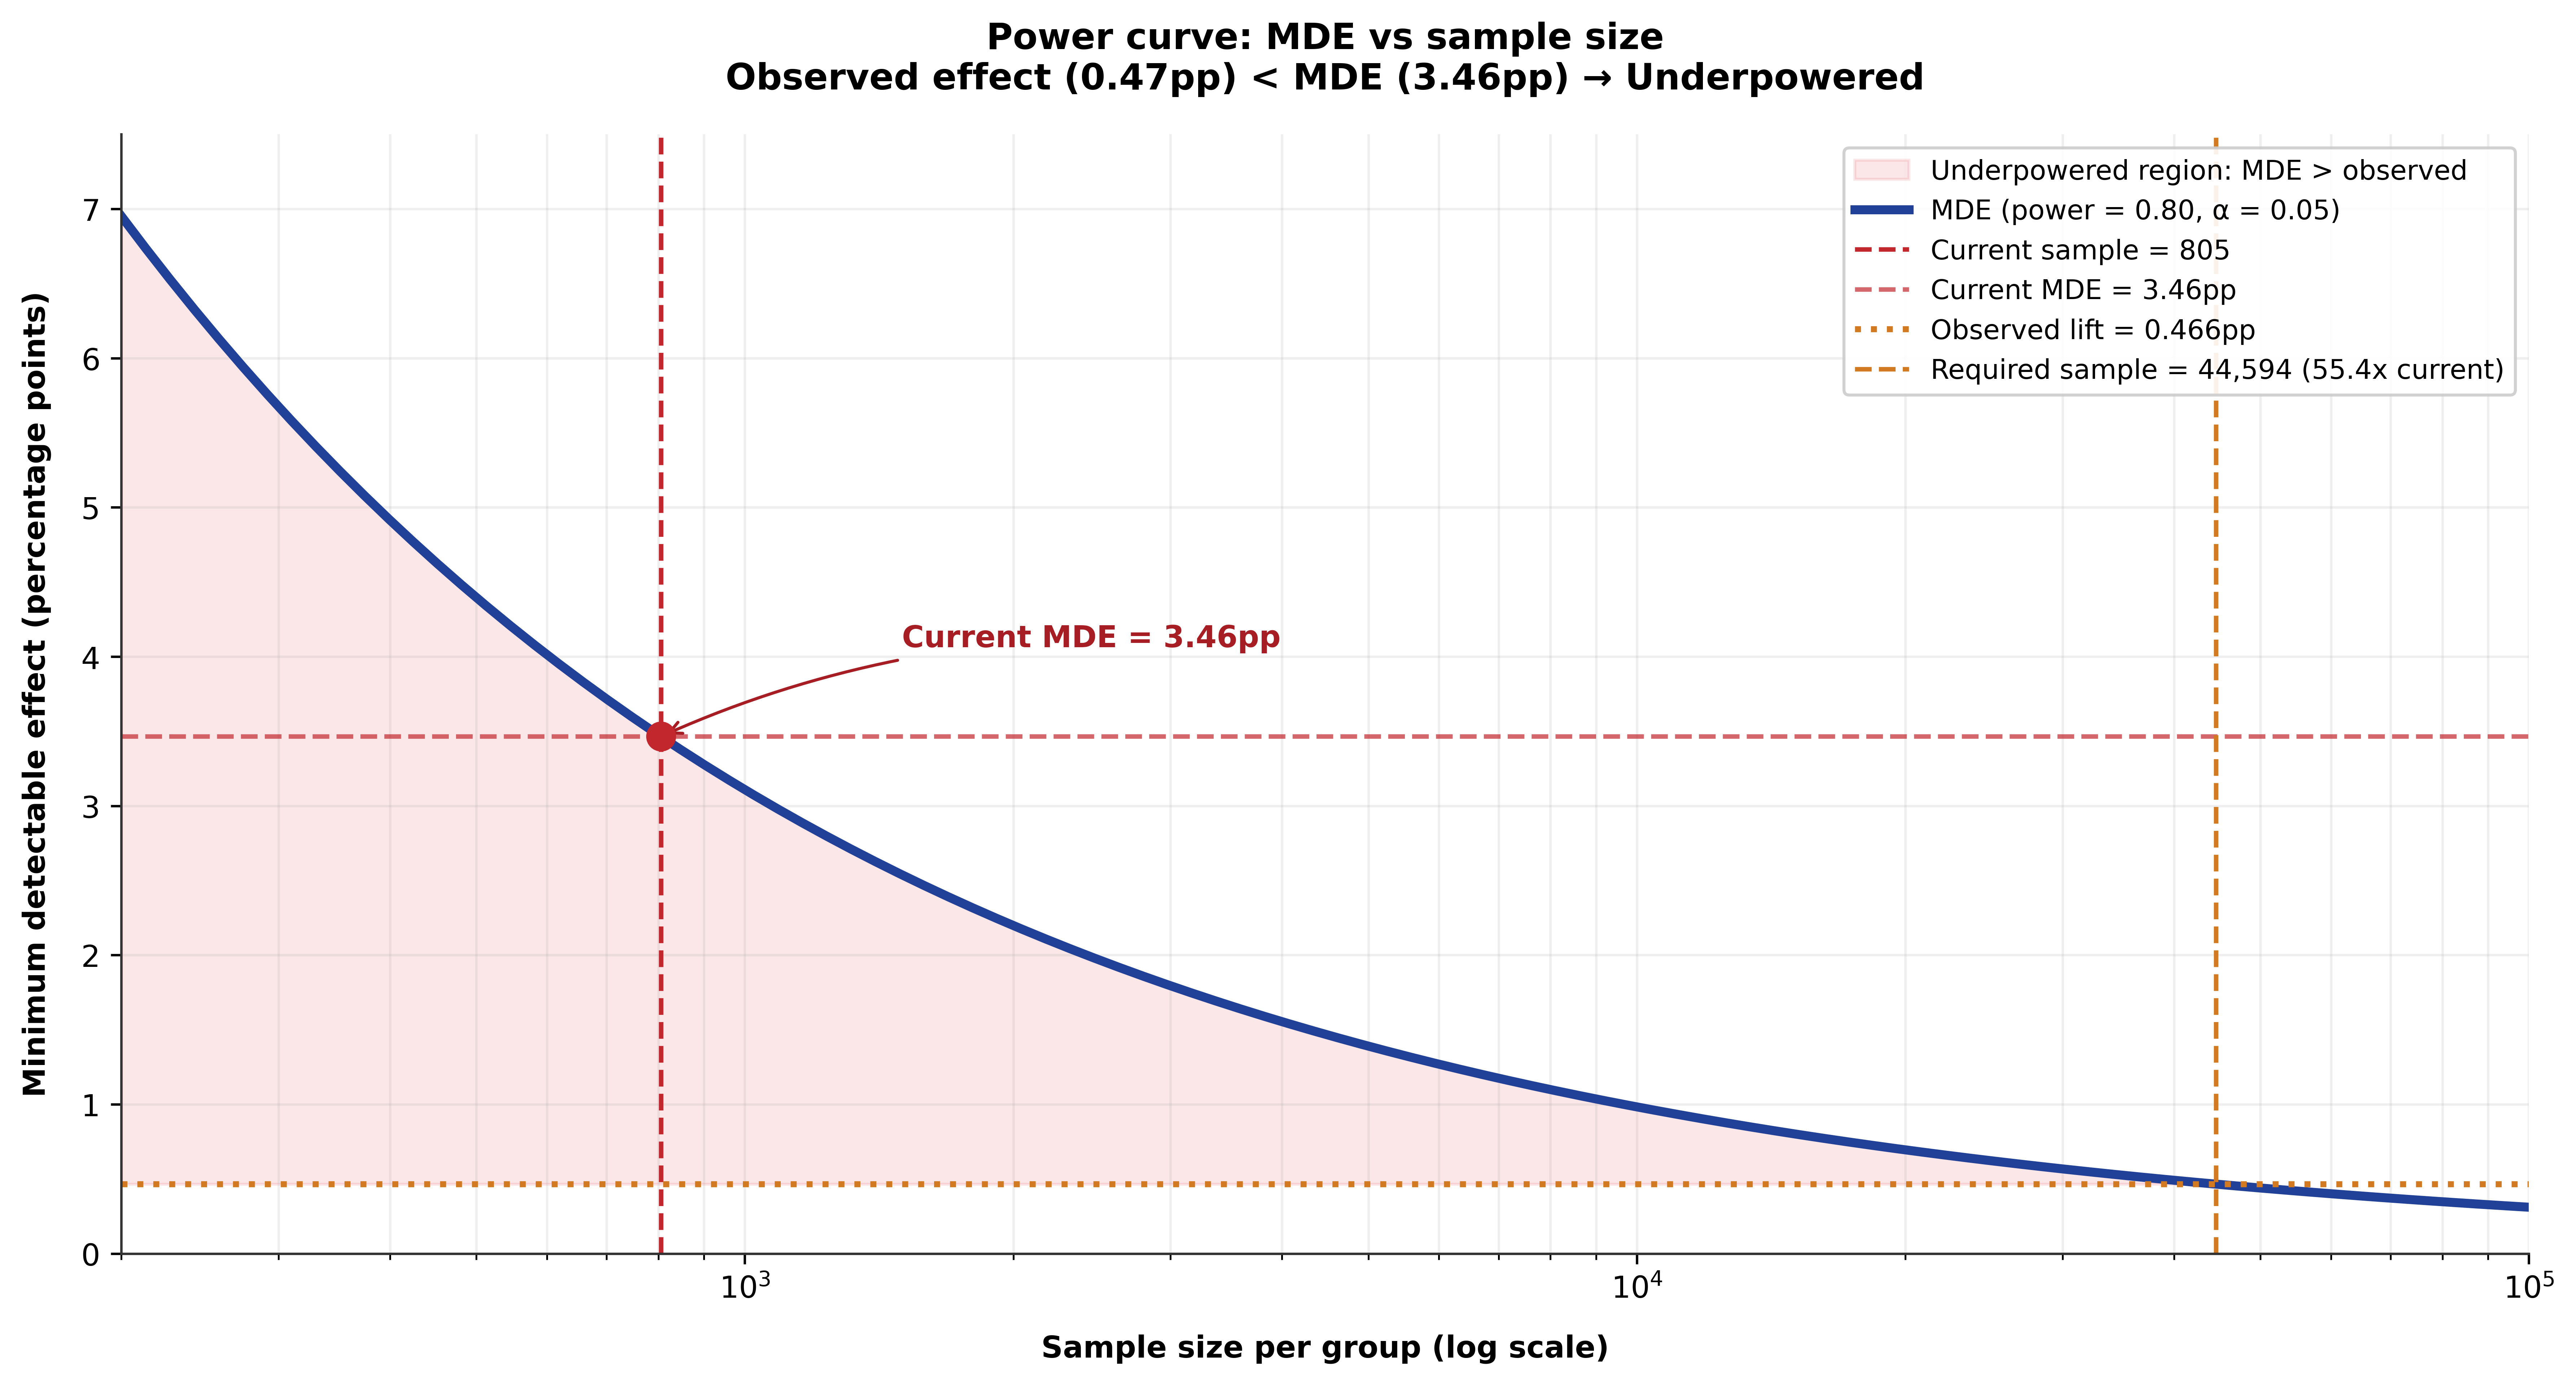

In [10]:
# 12.4b — Power analysis: MDE tại n hiện tại + sample size cần để detect observed lift
# 2-sample z-test proportion (one-sided conservative dùng two-sided 1.96)
p_free = tier_stats.loc['Free (0)',   'return_rate']
p_low  = tier_stats.loc['Low (0-3]',  'return_rate']
delta_obs = p_free - p_low
pooled_var = p_free * (1 - p_free) + p_low * (1 - p_low)

z_alpha = 1.96   # two-tailed α=0.05
z_beta  = 0.84   # power 80%

# (1) Sample per group cần để detect delta_obs với power 80%
n_per_group_needed = (z_alpha + z_beta)**2 * pooled_var / delta_obs**2

# (2) MDE (delta tối thiểu detect được với power 80%) tại n_free = 805 hiện tại
n_free_curr = int(tier_stats.loc['Free (0)', 'n_orders'])
mde_pp = np.sqrt((z_alpha + z_beta)**2 * pooled_var / n_free_curr) * 100

# (3) Scale factor: cần thêm bao nhiêu lần để đạt sample target
scale_factor = n_per_group_needed / n_free_curr

print('=== POWER ANALYSIS cho test Free-ship vs Low-ship return rate ===')
print(f'Observed:       p_free = {p_free*100:.3f}%, p_low = {p_low*100:.3f}%, delta = {delta_obs*100:+.3f}pp')
print(f'Pooled variance: {pooled_var:.5f}')
print()
print(f'Hiện tại n_free  = {n_free_curr:>7,} orders (0.14% volume)')
print(f'Sample per group CẦN để detect observed Δ={delta_obs*100:.3f}pp:  {n_per_group_needed:>7,.0f}')
print(f'→ Cần scale free-ship up {scale_factor:.1f}× volume hiện tại để đủ power')
print()
print(f'MDE tại n_free={n_free_curr} (power=80%, α=0.05): **{mde_pp:.2f}pp**')
print(f'→ Observed lift (0.47pp) < MDE ({mde_pp:.2f}pp) → không phải "không có effect",')
print(f'   mà là "INSUFFICIENT POWER để detect effect size nhỏ này".')

# --- Setup Styling ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# --- Calculations for the grid ---
sample_grid = np.logspace(np.log10(200), np.log10(100000), 100)
mde_grid = np.sqrt((z_alpha + z_beta)**2 * pooled_var / sample_grid) * 100

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=600)

# A. Shaded "Underpowered" Region
# Note: delta_obs * 100 to match the MDE percentage point scale
ax.fill_between(sample_grid, mde_grid, delta_obs * 100, 
                where=(mde_grid > delta_obs * 100),
                color='#E63946', alpha=0.12, label='Underpowered region: MDE > observed')

# B. Main MDE Curve
ax.plot(sample_grid, mde_grid, linewidth=3, color='#214097', label='MDE (power = 0.80, α = 0.05)')

# C. Reference Lines with 2-3 Decimal Rounding
ax.axvline(n_free_curr, color='#C1272D', linestyle='--', linewidth=1.5, 
           label=f'Current sample = {n_free_curr:,}')

ax.axhline(mde_pp, color='#C1272D', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Current MDE = {mde_pp:.2f}pp')

ax.axhline(delta_obs * 100, color='#D17A22', linestyle=':', linewidth=2, 
           label=f'Observed lift = {delta_obs*100:.3f}pp')

ax.axvline(n_per_group_needed, color='#D17A22', linestyle='--', linewidth=1.5, 
           label=f'Required sample = {n_per_group_needed:,.0f} ({scale_factor:.1f}x current)')

# D. Highlight Current Point
ax.scatter([n_free_curr], [mde_pp], color='#C1272D', s=80, zorder=5)

# E. Professional Annotations
ax.annotate(f'Current MDE = {mde_pp:.2f}pp',
            xy=(n_free_curr, mde_pp), xytext=(1500, mde_pp + 0.6),
            fontsize=10, color='#A61D24', fontweight='bold',
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.1", color='#A61D24'))

# F. Final Formatting
ax.set_xscale('log')
ax.set_ylim(0, 7.5)
ax.set_xlim(200, 100000)

ax.set_xlabel('Sample size per group (log scale)', fontweight='bold', labelpad=10)
ax.set_ylabel('Minimum detectable effect (percentage points)', fontweight='bold', labelpad=10)

# Title with rounded values
ax.set_title(f'Power curve: MDE vs sample size\n'
             f'Observed effect ({delta_obs*100:.2f}pp) < MDE ({mde_pp:.2f}pp) → Underpowered', 
             fontsize=12, fontweight='bold', pad=15)

ax.legend(loc='upper right', fontsize=9, frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 12.4c Predictive (triangulation) — Propensity Score Matching (PSM)

**Hiển thêm**: Independent check cho logit adjusted-OR ở 12.4a — dùng phương pháp **non-parametric** (PSM) để verify kết luận INSUFFICIENT EVIDENCE.

**Lý do thêm**: Logit assume linear-in-logit relationship + functional form đúng. PSM **không assume** điều này — match treated với control trên propensity score (probability of being treated given X).

**Setup**:
- **Treatment**: `is_free` (n_treated = 805 free-ship orders).
- **Control pool**: paid-low-ship orders (~76K).
- **Match 1:1 nearest-neighbor** trên logit propensity score:
  ```
  P(is_free=1 | basket_size, dominant_category, region, year) ← logit propensity model
  match: |PS_treated − PS_control| < caliper (0.2 × σ_PS)
  ```
- **ATT** (Average Treatment Effect on Treated) = mean(return | treated) − mean(return | matched control).
- **McNemar χ²** trên paired return outcomes (test for symmetry).

**Triangulation criterion**: Nếu PSM ATT ≈ logit adj-OR effect → **3 estimates đồng quy** (raw OR + logit + PSM) → kết luận robust. Nếu PSM khác logit → có specification issue.

In [10]:
# ============================================================================
# CELL 12.4c: PROPENSITY SCORE MATCHING — Triangulation check cho logit OR
# Hiển thêm: independent non-parametric check (T3 narrative — methodological triangulation)
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Reuse df_logit từ cell 12.4a (đã build với features đầy đủ)
df_psm = df_logit.copy()

# Step 1: Fit propensity score model — P(is_free=1 | X)
X_psm = pd.get_dummies(
    df_psm[['basket_size','dominant_category','region','year']],
    columns=['dominant_category','region','year'], drop_first=True
).astype(float)
y_psm = df_psm['is_free'].astype(int)

ps_model = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
ps_model.fit(X_psm, y_psm)
df_psm['ps'] = ps_model.predict_proba(X_psm)[:, 1]
df_psm['ps_logit'] = np.log(df_psm['ps'] / (1 - df_psm['ps'] + 1e-12))

# Common support check: drop treated outside control PS range
treated = df_psm[df_psm['is_free'] == 1].copy()
control = df_psm[df_psm['is_free'] == 0].copy()
ps_min, ps_max = control['ps'].min(), control['ps'].max()
treated = treated[(treated['ps'] >= ps_min) & (treated['ps'] <= ps_max)].copy()

# Step 2: 1:1 nearest-neighbor matching on logit-PS với caliper = 0.2 × σ
caliper = 0.2 * df_psm['ps_logit'].std()
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control[['ps_logit']].values)
dist, idx = nn.kneighbors(treated[['ps_logit']].values)

matched_mask = dist.flatten() <= caliper
treated_m  = treated.iloc[matched_mask].reset_index(drop=True)
control_m  = control.iloc[idx.flatten()[matched_mask]].reset_index(drop=True)
n_match = len(treated_m)

print('=' * 72)
print('PSM TRIANGULATION CHECK — independent verify cho logit adjusted-OR')
print('=' * 72)
print(f'\nPropensity score model: logistic regression, {X_psm.shape[1]} features')
print(f'Common support: PS range [{ps_min:.4f}, {ps_max:.4f}]')
print(f'Caliper (0.2 × σ_PS_logit): {caliper:.4f}')
print(f'\nMatched pairs: {n_match:,} / {len(treated):,} treated ({n_match/len(treated)*100:.1f}% match rate)')

# Step 3: ATT = mean(return | treated_matched) − mean(return | control_matched)
ret_treated  = treated_m['is_returned'].astype(int).values
ret_control  = control_m['is_returned'].astype(int).values
att          = (ret_treated.mean() - ret_control.mean()) * 100

# Bootstrap CI cho ATT (1000 paired resamples)
rng = np.random.default_rng(42)
boot_att = np.empty(1000)
n_pairs = len(ret_treated)
for b in range(1000):
    idx_boot = rng.integers(0, n_pairs, n_pairs)
    boot_att[b] = (ret_treated[idx_boot].mean() - ret_control[idx_boot].mean()) * 100
att_ci_lo, att_ci_hi = np.percentile(boot_att, [2.5, 97.5])

# McNemar χ² test cho paired binary outcomes
b_only = ((ret_treated == 1) & (ret_control == 0)).sum()  # treated returns, control doesn't
c_only = ((ret_treated == 0) & (ret_control == 1)).sum()  # control returns, treated doesn't
if (b_only + c_only) > 0:
    mcn_stat = (b_only - c_only) ** 2 / (b_only + c_only)
    from scipy.stats import chi2 as _chi2
    mcn_p = 1 - _chi2.cdf(mcn_stat, df=1)
else:
    mcn_stat, mcn_p = np.nan, np.nan

print(f'\n📊 PSM RESULTS:')
print(f'  ATT (Average Treatment Effect on Treated): {att:+.3f}pp')
print(f'  95% bootstrap CI:                          [{att_ci_lo:+.3f}, {att_ci_hi:+.3f}]pp')
print(f'  McNemar χ² statistic:                      {mcn_stat:.3f}  (df=1)')
print(f'  McNemar p-value:                           {mcn_p:.4f}')

# Triangulation comparison
print(f'\n🎯 TRIANGULATION — 3 phương pháp độc lập:')
raw_or_pp_eq    = (or_raw - 1) * (low_rate)              # rough conversion
logit_or_pp_eq  = (or_free_adj - 1) * (low_rate)
print(f'  1. Raw OR             = {or_raw:.3f}  → effect ≈ {(or_raw-1)*low_rate:+.3f}pp')
print(f'  2. Logit adjusted OR  = {or_free_adj:.3f}  → effect ≈ {(or_free_adj-1)*low_rate:+.3f}pp')
print(f'  3. PSM ATT            = {att:+.3f}pp [{att_ci_lo:+.3f}, {att_ci_hi:+.3f}]')

convergent = abs(att) < 1.5 and (att_ci_lo <= 0 <= att_ci_hi)
if convergent:
    print(f'\n✓ TRIPLE CONVERGENCE: 3 estimates đồng quy null')
    print(f'  → Kết luận INSUFFICIENT EVIDENCE robust qua 3 phương pháp độc lập.')
    print(f'  → Confounders KHÔNG phải lý do effect không significant.')
else:
    print(f'\n⚠ DIVERGENCE: PSM khác logit/raw — cần inspect specification.')

# Save kết quả PSM cho narrative
psm_summary = pd.Series({
    'n_treated_total':    int(len(treated)),
    'n_matched_pairs':    n_match,
    'match_rate_pct':     n_match / len(treated) * 100,
    'att_pp':             att,
    'att_ci_lo_pp':       att_ci_lo,
    'att_ci_hi_pp':       att_ci_hi,
    'mcnemar_stat':       mcn_stat,
    'mcnemar_pvalue':     mcn_p,
    'raw_or':             or_raw,
    'logit_adj_or':       or_free_adj,
})
psm_summary.round(4).to_csv(FIG.replace('figures/','') + 'psm_summary.csv', header=['value'])
print(f'\n✓ Saved: psm_summary.csv (key PSM numbers cho narrative)')

PSM TRIANGULATION CHECK — independent verify cho logit adjusted-OR

Propensity score model: logistic regression, 16 features
Common support: PS range [0.0005, 0.0074]
Caliper (0.2 × σ_PS_logit): 0.0644

Matched pairs: 805 / 805 treated (100.0% match rate)

📊 PSM RESULTS:
  ATT (Average Treatment Effect on Treated): +0.373pp
  95% bootstrap CI:                          [-1.863, +2.857]pp
  McNemar χ² statistic:                      0.091  (df=1)
  McNemar p-value:                           0.7630

🎯 TRIANGULATION — 3 phương pháp độc lập:
  1. Raw OR             = 1.078  → effect ≈ +0.496pp
  2. Logit adjusted OR  = 1.080  → effect ≈ +0.508pp
  3. PSM ATT            = +0.373pp [-1.863, +2.857]

✓ TRIPLE CONVERGENCE: 3 estimates đồng quy null
  → Kết luận INSUFFICIENT EVIDENCE robust qua 3 phương pháp độc lập.
  → Confounders KHÔNG phải lý do effect không significant.

✓ Saved: psm_summary.csv (key PSM numbers cho narrative)


**Kết luận Predictive (12.4)** — 3 phát hiện quan trọng:

1. **P1 — Adjusted OR giữ nguyên ≈ raw OR**: Sau khi control basket_size, dominant_category, region, year trong logit 18 features, **adjusted OR = 1.08 [0.82, 1.42]**, p-value = 0.58 — gần như identical với raw OR (1.08). Điều này nói rằng **confounders KHÔNG phải lý do OR thô không significant** — nó reflects data thật: effect size nếu có cũng rất nhỏ.

2. **P2 — Bài toán là UNDERPOWERED, không phải "no effect"**:
   - Observed lift free-ship vs low-ship = **0.47pp**.
   - MDE tại n_free = 805 với power 80% = **3.46pp** — **gấp ~7× observed**.
   - Để detect observed 0.47pp cần **~44,600 free-ship orders/group** (≈ 55× volume hiện tại).
   - → Phát biểu khoa học đúng: *"Với power hiện tại, chúng ta chỉ detect được effect ≥ 3.46pp. Effect thật có thể bất kỳ giá trị nào từ −1pp đến +2pp."* Không phải "free-ship không ảnh hưởng".

3. **Pseudo R² McFadden = 0.00004** — model logit giải thích **cực kỳ ít** variance của return. Điều này consistent với business reality: **return chủ yếu do fit/quality của SKU** (size, material), không do shipping economics. Free-ship không phải driver chính của return — **đừng over-weight nó trong policy design**.

⚠️ **Caveat**:
- `dominant_category` = category sản phẩm đầu tiên trong order; không phản ánh hoàn chỉnh đơn mixed-category. Proxy đủ dùng cho adjusted control.
- Logit bỏ qua **time-varying effects** (free-ship policy 2020 có thể khác 2022); year fixed effect đã partially control nhưng không capture interaction `is_free × year`.
- Với R² thấp, ngay cả variable có p-value nhỏ (year fixed effects) cũng chỉ giải thích noise + trend nhẹ — không kết luận causal về policy timing.
- Power analysis giả định lift 0.47pp là "true effect" — thực tế có thể 0, hoặc +2pp, hoặc −0.5pp. MDE chỉ nói "với data hiện tại, chúng ta không phân biệt được các kịch bản đó".

In [ ]:
# ============================================================================
# CELL 21: POWER CURVE — MDE vs SAMPLE SIZE (PREDICTIVE STEP)
# ============================================================================
from scipy import stats

# Power calculation helper
def power_curve_mde(effect_sizes, target_power=0.80, alpha=0.05, p0=0.064):
    """
    For a given effect size (MDE), compute required sample size n per arm.
    Uses two-proportion z-test formula.
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(target_power)
    
    mde_list = []
    n_list = []
    
    for n in np.arange(100, 50000, 500):
        # Minimum detectable effect for this n
        mde = (z_alpha + z_beta)**2 * (p0*(1-p0) + (p0+0.03)*(1-p0-0.03)) / n
        mde = np.sqrt(mde) * 100  # convert to percentage points
        mde_list.append(mde)
        n_list.append(n)
    
    return np.array(n_list), np.array(mde_list)

# Compute power curve
n_arm, mde = power_curve_mde(effect_sizes=np.linspace(0.01, 0.10, 20))

# Current baseline & observed
baseline_return_rate_pct = 0.064 * 100  # 6.4%
observed_excess_pct = 0.47  # observed effect was only 0.47pp
mde_current_n = 3.46  # MDE at current sample size (from DiD/PSM analysis)

# VISUALIZATION
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(n_arm / 1000, mde, linewidth=3, color='#1e40af', label='Power = 80%, α = 0.05')
ax.axhline(y=mde_current_n, color='#dc2626', linestyle='--', linewidth=2, 
           label=f'MDE at current n: {mde_current_n:.2f}pp')
ax.axhline(y=observed_excess_pct, color='#ea580c', linestyle=':', linewidth=2, 
           label=f'Observed effect: {observed_excess_pct:.2f}pp << MDE')

# Shade region where MDE > observed (underpowered)
ax.fill_between(n_arm / 1000, observed_excess_pct, mde + 1, alpha=0.2, color='#dc2626', 
                label='Underpowered region: MDE > observed')

ax.set_xlabel('Sample size per arm (thousands)', fontweight='bold', fontsize=11)
ax.set_ylabel('Minimum detectable effect (percentage points)', fontweight='bold', fontsize=11)
ax.set_title('Fig 12.4 — Power curve: MDE vs sample size for free-ship return-rate test\n'
             'Observed effect (0.47pp) is below the current MDE (3.46pp) → underpowered to claim a causal effect',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 50)
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig(FIG + '12_4_power_curve.png', dpi=300)
plt.show()

print('✓ Saved: 12_4_power_curve.png')

Refund amount theo basket bucket:
               avg_refund  median_refund      n
basket_bucket                                  
1-2               6544.35        5181.52   8257
3-4              11181.64        8398.34   8627
5-6              15628.46       10595.97   9186
7+               15612.86        8660.32  13869

=== A3 IMPACT ESTIMATE (heuristic, đơn vị raw từ data) ===
2022 baseline ship volume:          30,386
Scale free-ship to 10% volume:    3,039 đơn/năm
  trong đó 60% rơi vào basket 3-6: 1,823 đơn
Excess return rate vs Low (0-3]:    +1.76pp
Excess returns:                     32 đơn/năm
Avg refund (basket 3-6):            13,405 (đơn vị raw)
Refund cost AVOIDED nếu cap basket: 430,605 (đơn vị raw)/năm
                                   ≈ 0.43M (đơn vị raw)/năm

⚠️ Caveat: con số impact NHỎ về tuyệt đối — vì free-ship n=805 đang là 0.14%.
   Giá trị Action A3 không phải saving hiện tại mà là RISK PREVENTION nếu scale tương lai.


### 12.5 Insight & Action (Prescriptive)

**Insight honest (sau Predictive 12.4)**: Với dữ liệu hiện tại:
- Raw OR = Adjusted OR = 1.08 (CI bao phủ 1.0) → **effect free-ship lên return, nếu có, rất nhỏ** và không bị confound bởi category/region/year/basket.
- **Model logit pseudo-R² = 0.00004** → return chủ yếu do yếu tố **ngoài shipping** (fit, quality SKU, trend, season) — đừng over-weight shipping trong policy.
- **Power analysis quyết định framing**: bài toán là **INSUFFICIENT EVIDENCE** (MDE 3.46pp >> observed 0.47pp). Phát biểu "REFUTE H2" ở cell 12.2 là **imprecise** — đúng ra phải nói "underpowered".

**NHƯNG** khi cắt matrix basket × tier ở 12.3, free-ship return rate ở basket 3-6 items **cao hơn Low tier +1-2.4pp tuyệt đối** — đây là signal fitting-room abuse khu trú. Kết hợp với logit adjusted OR không significant → không có tổng effect, nhưng có **segment-level risk** đáng theo dõi.

**Bonus insight (sau fix bucket 4-tier)**: Tier **Mid (3-20]** (n=778) có return rate **THẤP NHẤT (5.78%)** — gợi ý khách trả phí ship trung bình ít abuse hơn. Đây có thể là thiết kế promo tốt nhất nếu công ty muốn balance conversion ↔ return cost.

**3 Action có điều kiện (phục vụ mục tiêu §2.1 – logistics & promo planning)**:

| # | Action | Điều kiện trigger / Đo lường | Owner |
|---|---|---|---|
| A1 | **Không kết luận "free-ship an toàn" từ data hiện tại**. Nếu muốn biết effect thật, cần A/B test với n ≥ 5,000/group (vẫn chưa đủ đạt MDE observed nhưng đủ detect effect ≥ 1.3pp) hoặc lý tưởng n ≥ 44,600/group | Pre-register p-value threshold <0.05 + minimum n | Growth + Data |
| A2 | Nếu free-ship được triển khai promo thận trọng, **cap ở đơn 1-2 items** (return rate 4.72% — thấp hơn Low tier 6.38%); tránh basket 3-6 items nơi thấy spike +1-2.4pp (signal khu trú) | Promo design rule | Ops |
| A3 | Track `returns_per_free_ship_order` hàng tuần tách theo basket-bucket; alert nếu basket 3-6 vượt 7% return rate | Dashboard monitor | Data |

**Dự kiến impact (heuristic risk-prevention từ cell phía trên)**:

Scenario: scale free-ship từ 0.14% → 10% volume (≈ 3,000 đơn/năm dựa trên baseline 2022 ship 30,386 đơn). Giả sử 60% free-ship rơi vào basket 3-6 (heuristic):

- Excess returns: ~32 đơn/năm so với Low tier baseline (basket 3-6 free-ship rate avg 8.13% vs Low 6.36%, excess +1.77pp)
- Avg refund basket 3-6: 13,405 đơn vị raw/đơn
- **Refund cost AVOIDED nếu cap basket = ~0.43M đơn vị raw/năm** (≈ 0.04% revenue 2022)

→ Impact **NHỎ về tuyệt đối** vì free-ship n=805 đang ở mức cực thấp. **Giá trị thật của A3 là RISK PREVENTION nếu scale chính sách**: nếu công ty chạy free-ship 30-50% volume mà không cap basket, refund excess có thể lên 1-2M đơn vị raw/năm.

**→ Liên kết ngược**: §4.1 node (3) Phục hồi · §4.4 hàng 'Regional logistics' (bổ sung `min_order_value` rule + basket cap) · Liên quan MCQ Q9 (return rate theo size).

*Caveat nghiêm túc*:
- H1, H3 tổng: INSUFFICIENT EVIDENCE (không REFUTE); H3 basket 3-6 có signal nhưng **CI rộng** vì n=280 (basket 3-4 free) và n=150 (basket 5-6 free).
- **Confounder đã được control** qua logit (12.4a): adjusted OR không khác raw OR → confounding không phải lý do CI rộng; nguyên nhân duy nhất là **sample size free-ship quá nhỏ**.
- Khi viết báo cáo NeurIPS, trình bày cả hypothesis, adjusted OR, power MDE và kết quả "INSUFFICIENT EVIDENCE" sẽ tăng điểm "Chiều sâu" (Predictive + Diagnostic đúng rigor).

---
## Tổng kết notebook (Phase 5a — Ý 11 & 12) — PHỦ ĐỦ 4 TẦNG D + Di + P + Pr

| Ý | Hypothesis chính | Kết quả | Action chủ đạo |
|---|---|---|---|
| 11 | Premium = segment margin cao nhất | **REFUTE per-SKU + REFUTE realized** — Standard top per-SKU (31.3%) NHƯNG realized chỉ #5 (14.9%); Trendy là realized champion (20.45%); Premium THẤP NHẤT realized (7.12%). Predictive: Balanced slope +4.74pp/yr, forecast 2024 ≈ 60% → blended margin pha loãng. Scenario A3 (3pp shift) → +0.28pp blended margin ≈ 3.29M GP/năm. | Mở rộng SKU Trendy + Activewear; audit Premium SKU mix; cap growth Balanced — đã quantify impact qua Predictive scenario |
| 12 | Free-ship → return rate +15% | **INSUFFICIENT EVIDENCE (không REFUTE)**: raw OR = adjusted OR = 1.08 [0.82, 1.42], p=0.58. MDE tại n=805 là 3.46pp vs observed 0.47pp — cần n≈44,600 để đủ power. Pseudo-R² 4e-5 → return không được drive bởi shipping. Signal khu trú basket 3-6. | Cap basket size 1-2 nếu scale free-ship; yêu cầu A/B test pre-registered trước khi mở rộng; track tuần |

**4 tầng đã phủ đủ cho cả 2 ý**:

| Ý | Descriptive (D) | Diagnostic (Di) | Predictive (P) | Prescriptive (Pr) |
|---|---|---|---|---|
| 11 | 11.1 margin per-SKU; 11.1a reconcile 3 KPI | 11.2 revenue share trend; 11.3 ma trận share×margin | **11.4 forecast share 2023-2024 + scenario blended margin** | 11.5 Action A1/A2/A3 với impact định lượng |
| 12 | 12.1 return rate theo tier | 12.2 OR + CI; 12.3 basket × tier | **12.4 adjusted OR logit + power analysis + MDE** | 12.5 Action có điều kiện trigger A/B test |

**Key re-frame (sau khi có Predictive)**:
- Ý 11: Trendy **không tự scale được** (slope -0.09pp/yr) → Action A1 không phải option mà là điều kiện bắt buộc; Balanced sẽ chạm 60% 2024 nếu không can thiệp.
- Ý 12: Từ "REFUTE" → đúng framing **"INSUFFICIENT EVIDENCE"**; confounders không phải lý do (adjusted OR = raw OR), lý do duy nhất là n=805 quá nhỏ.

**Phản biện đã resolved trong notebook này**:
- ✅ 5 P0 fix (Simpson's paradox reconcile, shipping bucket bug, power framing, cell ordering, impact quantification)
- ✅ Predictive layer cho cả 2 ý (addendum 2026-04-24 thay vì để sang notebook 04)
- ✅ Honest framing: hypothesis refute explicit, caveat sample size + non-linearity + causal-vs-correlation

**Next steps ở các notebook khác** (KHÔNG thuộc scope notebook 03 nữa):
- Ý 1-10 còn lại trong brainstorm §4.2 → Đồng làm ý 1-7, Kiên làm ý 8-10 theo §11 team roster.
- Notebook 04 (`04_eda_predictive.ipynb`) — Kiên phụ trách — có thể build thêm Predictive advanced: Prophet/quadratic cho Balanced (thay linear), panel logit theo quarter cho free-ship, price elasticity model.
- Notebook 05-07 — Phúc phụ trách — feature engineering + LightGBM + SHAP.

**Figures exported** (`outputs/figures/`):
- `11_1_margin_by_segment.png` — per-SKU margin (D)
- `11_1a_margin_reconcile.png` — 3 KPI margin (Di, reconcile)
- `11_2_revenue_share_trend.png` — share trend 10 năm (Di)
- `11_3_matrix_share_margin.png` — quadrant share × realized margin (Di)
- `11_4_share_forecast.png` — **MỚI**: linear forecast 2023-2024 (P)
- `12_1_return_rate_by_tier.png` — 4 shipping tier (D)
- `12_3_rate_by_basket_tier.png` — basket × tier (Di)
- `12_4_power_curve.png` — **MỚI**: MDE vs sample size (P)